## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cpu') #torch.device('cpu') #torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
import random
# 1. Define the custom transform
class RandomDropGreenChannel:
    """Randomly turns off the Green channel (RGB -> R0B) with probability p."""
    def __init__(self, p=0.2):
        self.p = p
        
    def __call__(self, tensor):
        # Apply the dropout randomly based on probability p
        if random.random() < self.p:
            # Clone to avoid unexpected in-place modification warnings
            tensor = tensor.clone() 
            # PyTorch tensors are (C, H, W). Index 1 is Green.
            tensor[1, :, :] = 0.0 
        return tensor

class RandomDropRedChannel:
    """Randomly turns off the Red channel (RGB -> R0B) with probability p."""
    def __init__(self, p=0.2):
        self.p = p
        
    def __call__(self, tensor):
        if random.random() < self.p:
            tensor = tensor.clone() 
            tensor[0, :, :] = 0.0 
        return tensor

class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='data//hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
imageSize = 32
train_transform = transforms.Compose([
                                        transforms.Resize((imageSize, imageSize)), #transforms.RandomResizedCrop(imageSize, scale=(0.5, 1.0)),
                                        #transforms.RandomRotation(360),
                                        transforms.RandomVerticalFlip(),
                                        transforms.ColorJitter(hue=0.0, saturation=0.1),
                                        transforms.RandomGrayscale(p=0),
                                        transforms.ToTensor(),
                                        RandomDropRedChannel(p=0),
                                        RandomDropGreenChannel(p=0)
                                    ])
test_transform = transforms.Compose([
                                        transforms.Resize((imageSize, imageSize)), 
                                        transforms.ToTensor(),
                                    ])


batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

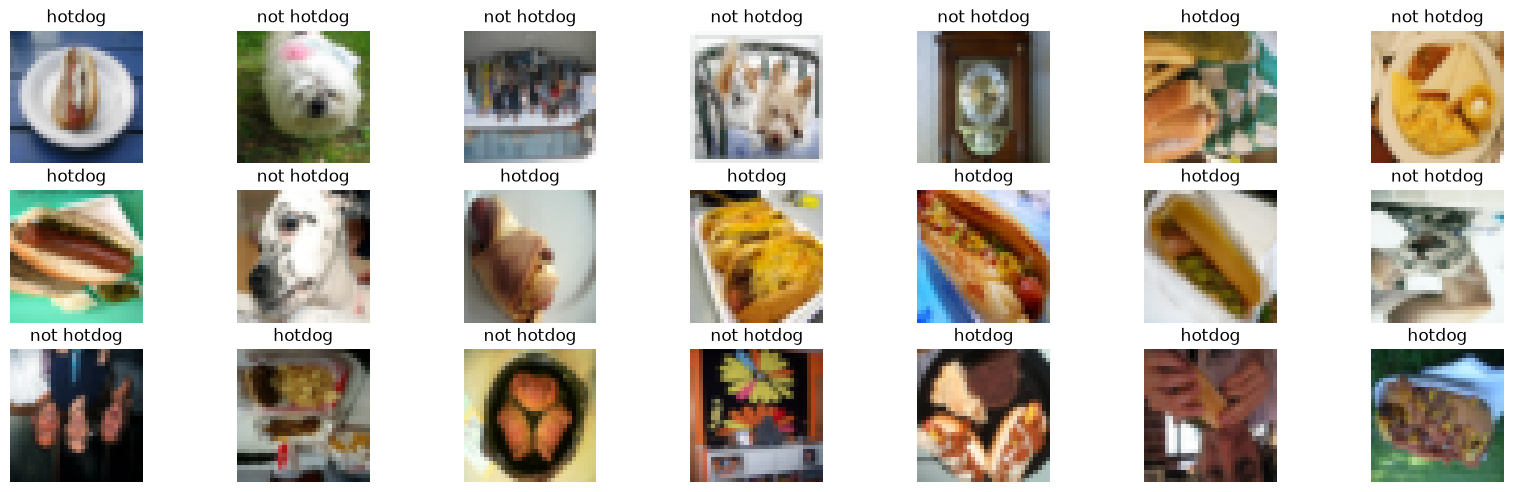

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [ ]:
imagesizeRatio = imageSize / 128 
print(imagesizeRatio)

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
            #2 Convolution layer that turns 3 RGB channels into 16 feature channels
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            #nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            #nn.ReLU(),

            #MaxPooling, from 128 to 64
            nn.MaxPool2d(2,2),

            #2 Convolution layers, going from 16 feature channels to 32
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),

            #MaxPooling, from 64 to 32
            nn.MaxPool2d(2,2),

            #2 Convolution layers, going from 32 feature channels to 64
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),

            #MaxPooling, from 32 to 16
            nn.MaxPool2d(2,2)
        )

        #Now we can build our fully connected network
        self.fully_connected = nn.Sequential(
            nn.Linear(int(64 * 16 * 16 * imagesizeRatio * imagesizeRatio), 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x

0.25


Training

In [7]:
def CreateAndTrainModel(learningRate: float, weightDecay: float, num_epochs: int, withoutProgressBar: bool):
    model_adam_final = Network().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_adam_final.parameters(), lr=learningRate, weight_decay=weightDecay)

    data = next(iter(train_loader))[0].to(device)
    print('Shape of the output from the convolutional part', model_adam_final.convolutional(data).shape)
    model_adam_final(data)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # TRAIN
        model_adam_final.train()
        running_train_loss, correct_train, total_train = 0.0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model_adam_final(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        epoch_train_loss = running_train_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        
        # VALIDATE
        model_adam_final.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                
                outputs = model_adam_final(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
                
        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1:02d} | "
            f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")
        
    return {
        "model": model_adam_final,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accuracies,
        "val_acc": val_accuracies,
    }

In [8]:
results = CreateAndTrainModel(0.001, 1e-4, 15, True)
model = results["model"]

Shape of the output from the convolutional part torch.Size([64, 64, 4, 4])


Epoch 01/15 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/15 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.6779, Train Acc: 57.55% | Val Loss: 0.6453, Val Acc: 67.83%


Epoch 02/15 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.4618, Train Acc: 79.78% | Val Loss: 0.5060, Val Acc: 74.38%


Epoch 15/15 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.4599, Train Acc: 79.58% | Val Loss: 0.5079, Val Acc: 76.26%


442 of 1862 test images misclassified (23.7%)


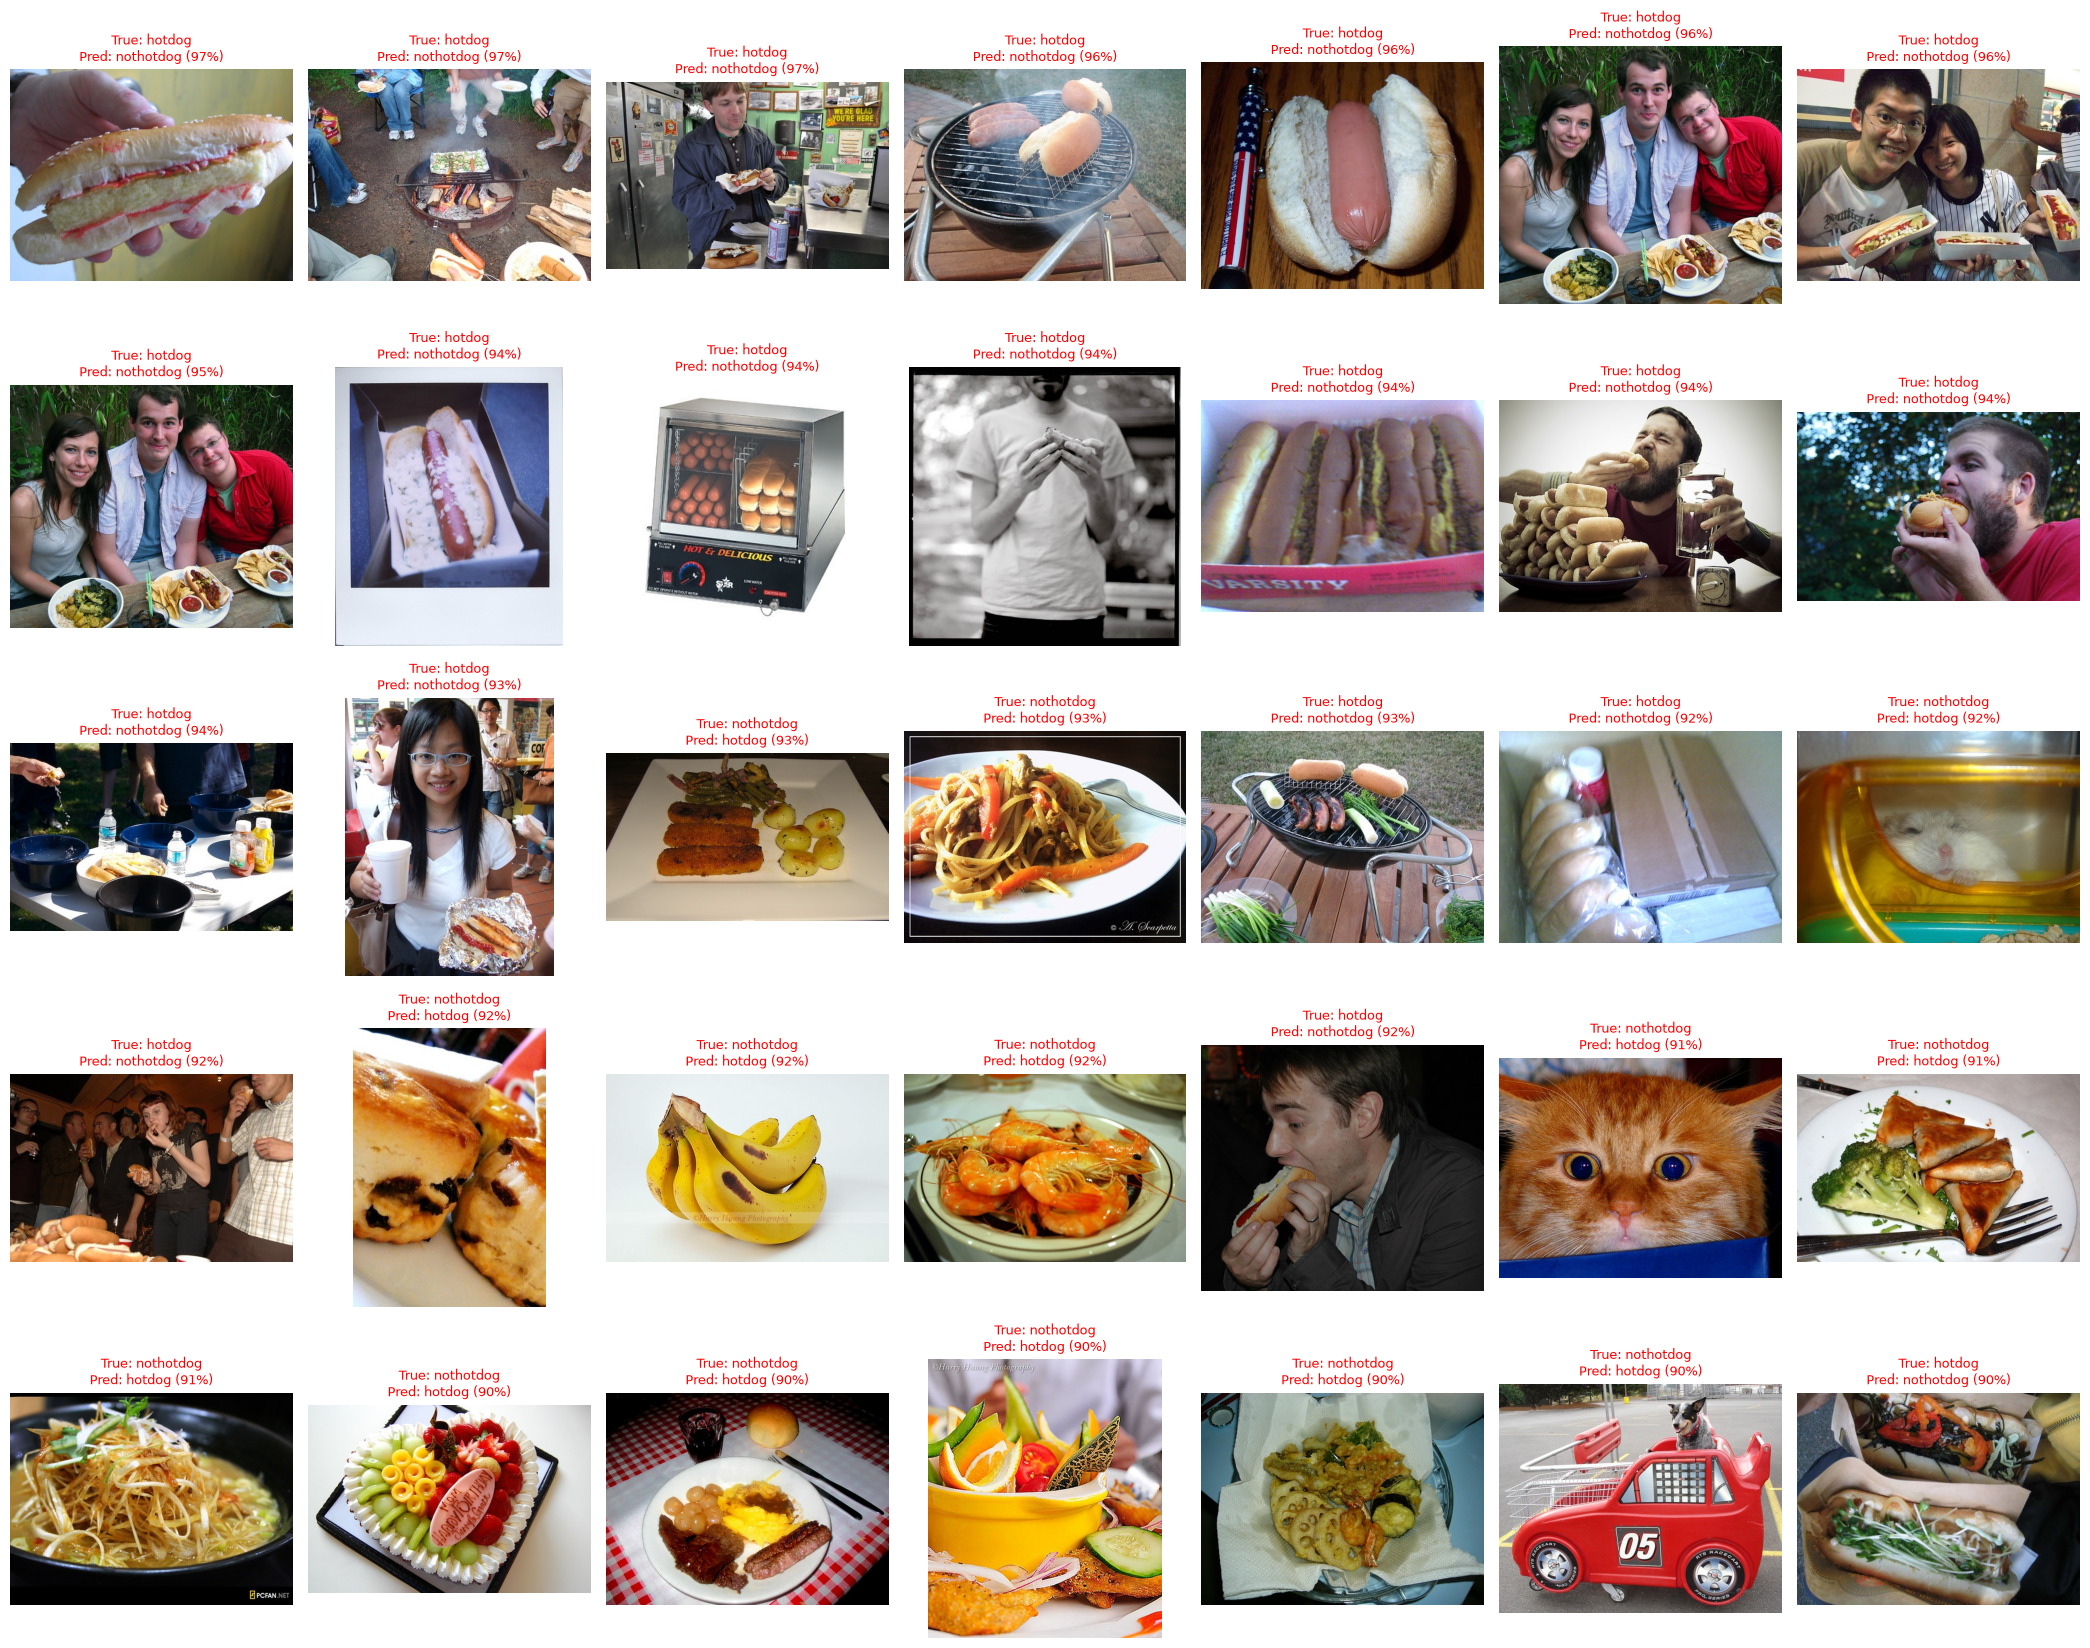

In [9]:
# Show test images the classifier got wrong
SHOW_MODEL_INPUT = False  # True = show the 32x32 no-green tensor the model saw; False = original photo
N_SHOW = 35
COLS = 7

model.eval()
idx_to_name = {v: k for k, v in testset.name_to_label.items()}

wrong = []  # (dataset index, true label, predicted label, confidence)
offset = 0
with torch.no_grad():
    for images, labels in test_loader:  # shuffle=False, so order matches testset.image_paths
        probs = F.softmax(model(images.to(device)), dim=1).cpu()
        conf, preds = probs.max(1)
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong.append((offset + i, labels[i].item(), preds[i].item(), conf[i].item()))
        offset += len(labels)

print(f"{len(wrong)} of {len(testset)} test images misclassified "
      f"({100 * len(wrong) / len(testset):.1f}%)")

if wrong:
    # Most confident mistakes first
    wrong.sort(key=lambda w: w[3], reverse=True)
    shown = wrong[:N_SHOW]
    rows = int(np.ceil(len(shown) / COLS))
    plt.figure(figsize=(COLS * 3, rows * 3.3))

    for k, (idx, y, p, c) in enumerate(shown):
        if SHOW_MODEL_INPUT:
            img = testset[idx][0].permute(1, 2, 0).numpy()
        else:
            img = Image.open(testset.image_paths[idx]).convert('RGB')
        plt.subplot(rows, COLS, k + 1)
        plt.imshow(img)
        plt.title(f"True: {idx_to_name[y]}\nPred: {idx_to_name[p]} ({c:.0%})",
                  fontsize=9, color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

442 of 1862 test images misclassified (23.7%)


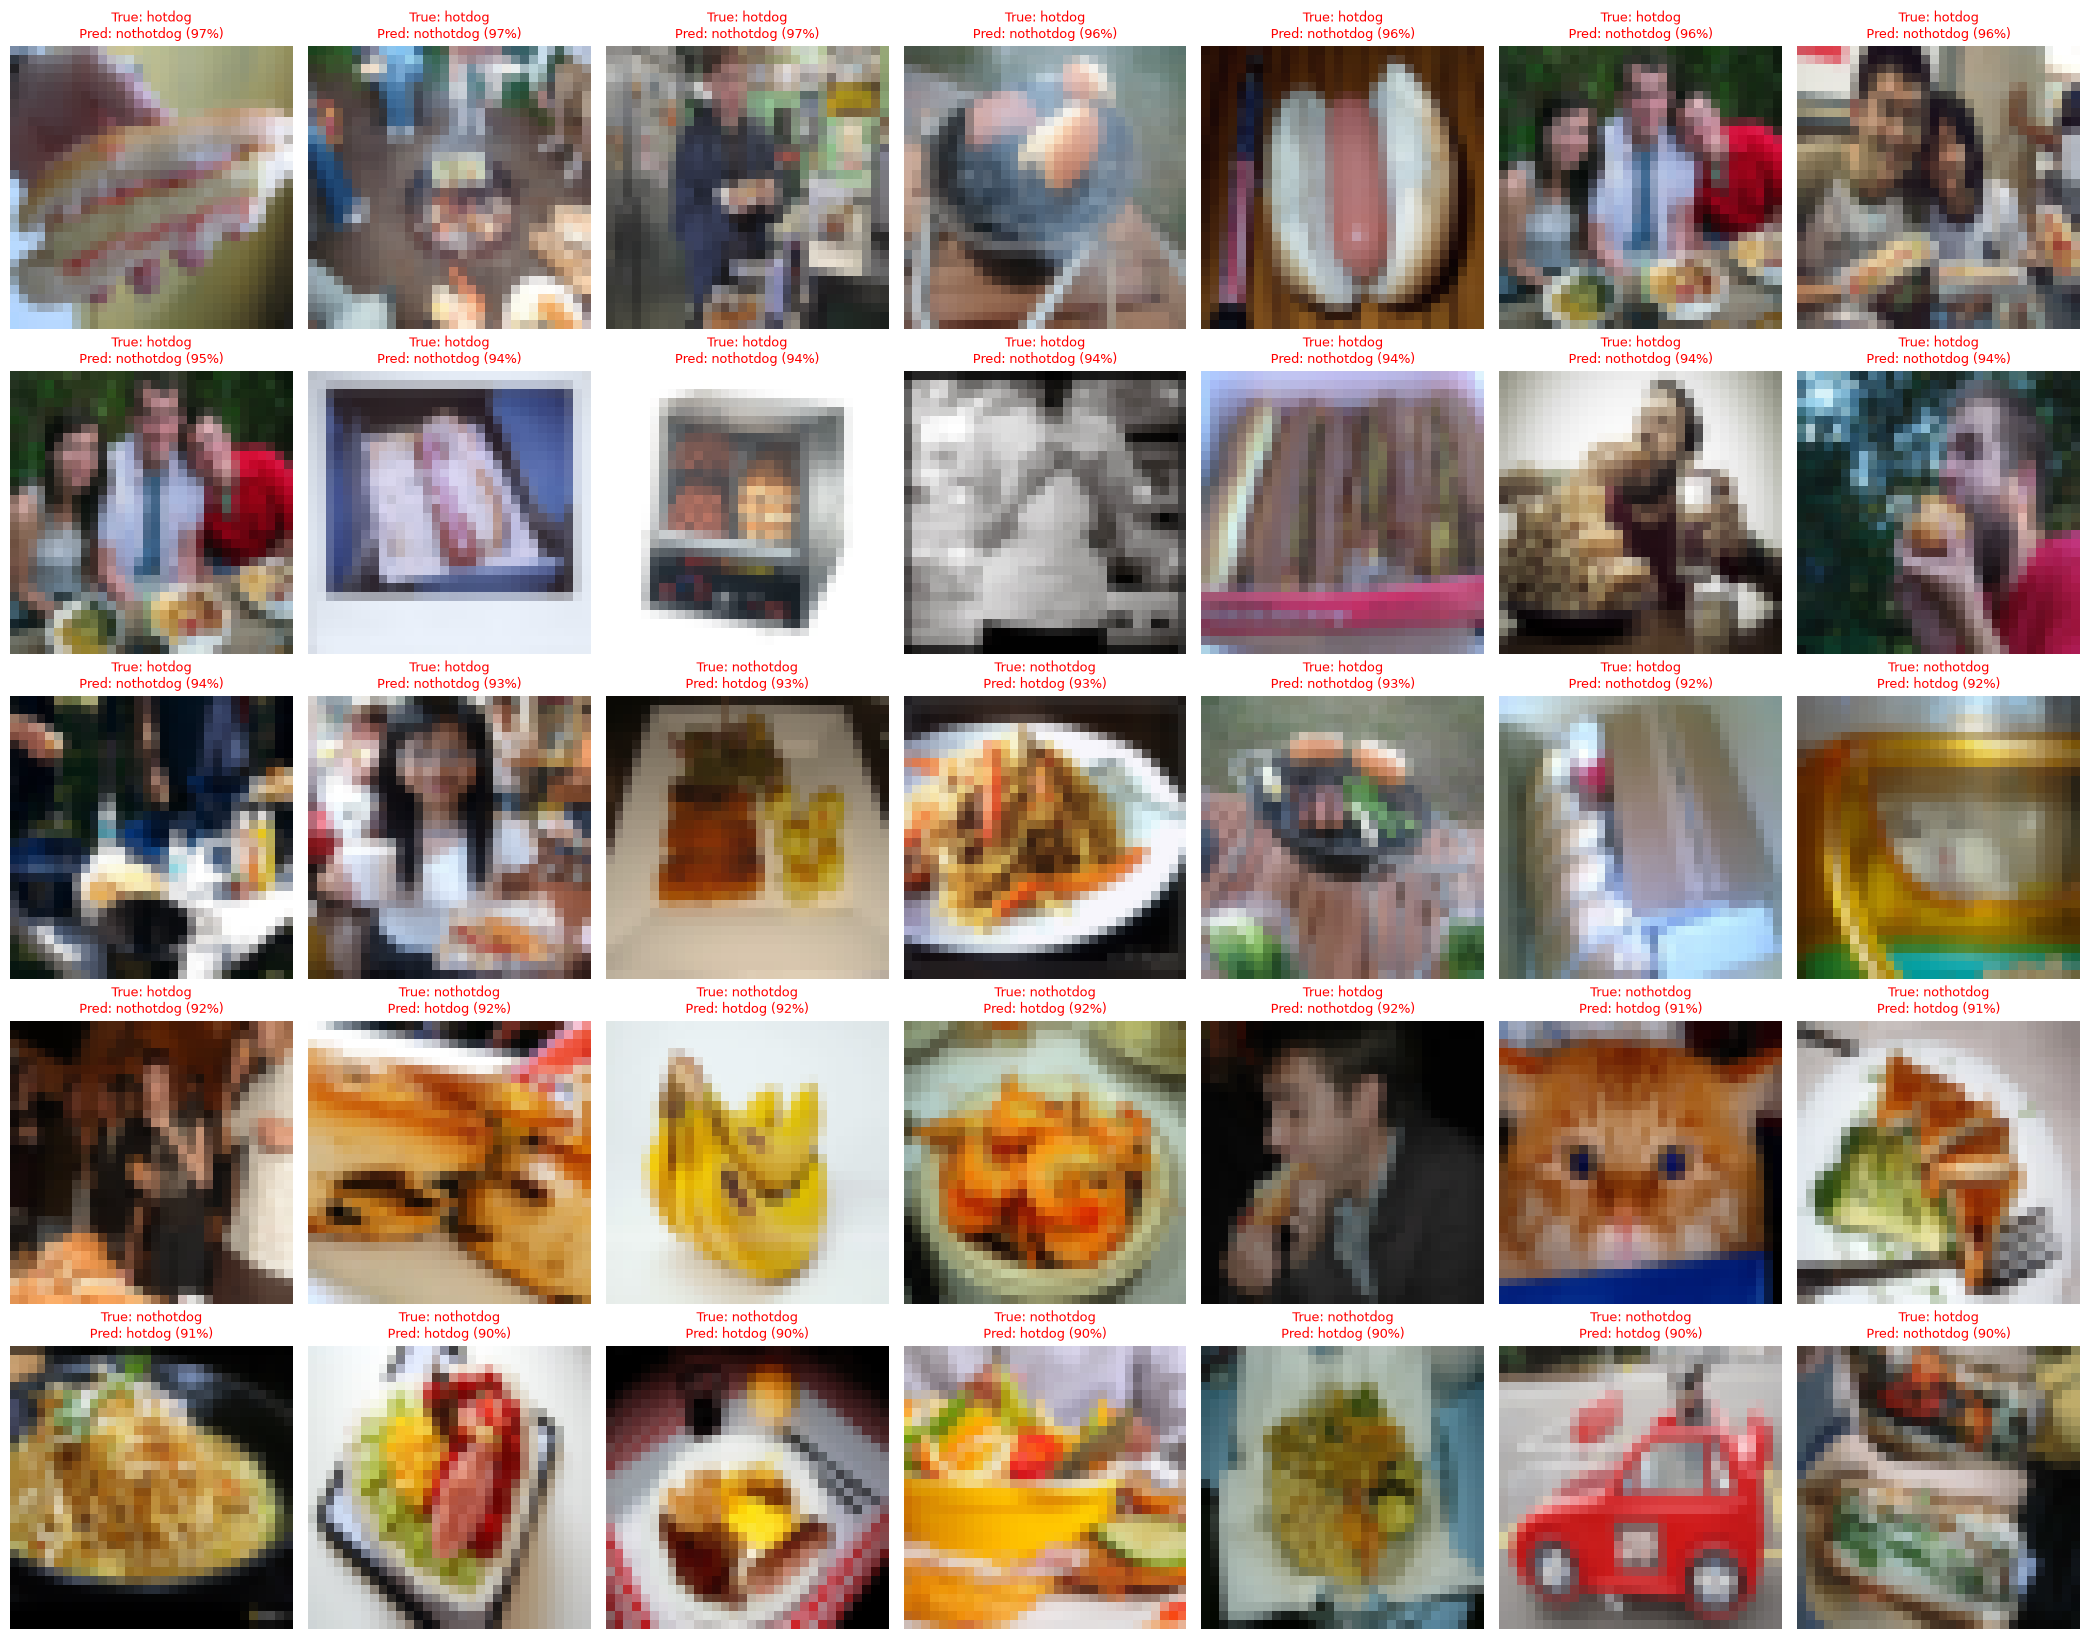

In [10]:
# Show test images the classifier got wrong
SHOW_MODEL_INPUT = True  # True = show the 32x32 no-green tensor the model saw; False = original photo
N_SHOW = 35
COLS = 7

model.eval()
idx_to_name = {v: k for k, v in testset.name_to_label.items()}

wrong = []  # (dataset index, true label, predicted label, confidence)
offset = 0
with torch.no_grad():
    for images, labels in test_loader:  # shuffle=False, so order matches testset.image_paths
        probs = F.softmax(model(images.to(device)), dim=1).cpu()
        conf, preds = probs.max(1)
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong.append((offset + i, labels[i].item(), preds[i].item(), conf[i].item()))
        offset += len(labels)

print(f"{len(wrong)} of {len(testset)} test images misclassified "
      f"({100 * len(wrong) / len(testset):.1f}%)")

if wrong:
    # Most confident mistakes first
    wrong.sort(key=lambda w: w[3], reverse=True)
    shown = wrong[:N_SHOW]
    rows = int(np.ceil(len(shown) / COLS))
    plt.figure(figsize=(COLS * 3, rows * 3.3))

    for k, (idx, y, p, c) in enumerate(shown):
        if SHOW_MODEL_INPUT:
            img = testset[idx][0].permute(1, 2, 0).numpy()
        else:
            img = Image.open(testset.image_paths[idx]).convert('RGB')
        plt.subplot(rows, COLS, k + 1)
        plt.imshow(img)
        plt.title(f"True: {idx_to_name[y]}\nPred: {idx_to_name[p]} ({c:.0%})",
                  fontsize=9, color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()